In [2]:
import pyterrier as pt
import pandas as pd

all_datasets = pt.list_datasets()
dataset = pt.get_dataset("msmarco_passage")
index = dataset.get_index(variant="terrier_stemmed")

# Load DL-hard annotations
annotations_url = "https://raw.githubusercontent.com/grill-lab/DL-Hard/main/annotations/query/annotations.tsv"
annotations = pd.read_csv(
    annotations_url,
    sep="\t",
    header=None,
    names=["qid", "query", "intent", "answer_type", "topic_domain", "serp_type"],
)
annotations["qid"] = annotations["qid"].astype(str)

# Load TREC DL 2019/2020 qrels. This dataset contains relevance judgements from scale 0 to 3.
dl19 = pt.get_dataset("irds:msmarco-passage/trec-dl-2019")
dl20 = pt.get_dataset("irds:msmarco-passage/trec-dl-2020")
all_qrels = pd.concat([dl19.get_qrels(), dl20.get_qrels()])
all_qrels["qid"] = all_qrels["qid"].astype(str)
# all_qrels = dataset.get_qrels()

# Keep only queries that have both annotations and judgements.
qrels_qids = set(all_qrels["qid"].unique())
# topics = dataset.get_topics()
topics = annotations[annotations["qid"].isin(qrels_qids)].reset_index(drop=True)

print(f'qrels: \n{all_qrels}')
print(f'Dataset: \n{topics}')

print(f"Queries with both annotations and relevance values: {len(topics)}")
# print(topics["intent"].value_counts())
print("\n")
# print(topics["answer_type"].value_counts())
topics["query_length"] = topics["query"].str.len()
print(f'Max len: {topics["query_length"].max()}')
print(f"topics: \n{topics}")
max_len = int(topics["query_length"].max())
bins = range(0, max_len + 10, 10)

topics["query_length_group"] = pd.cut(topics["query_length"], bins=bins, labels=[f"{i+1}-{i+10}" for i in bins][:-1])


qrels: 
           qid    docno  label iteration
0        19335  1017759      0        Q0
1        19335  1082489      0        Q0
2        19335   109063      0        Q0
3        19335  1160863      0        Q0
4        19335  1160871      0        Q0
...        ...      ...    ...       ...
11381  1136962  8526087      0         0
11382  1136962  8537921      0         0
11383  1136962  8742482      0         0
11384  1136962   937258      1         0
11385  1136962   999215      0         0

[20646 rows x 4 columns]
Dataset: 
        qid                                              query       intent  \
0   1115776                what is an aml surveillance analyst  description   
1   1136047  difference between a company's strategy and bu...  description   
2    915593          what types of food can you cook sous vide         list   
3     42255    average salary for dental hygienist in nebraska     quantity   
4    324585       how much money do motivational speakers make     qu

In [4]:
pip install python-terrier==0.13.2

  Attempting uninstall: python-terrier
    Found existing installation: python-terrier 1.0
    Uninstalling python-terrier-1.0:
      Successfully uninstalled python-terrier-1.0

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [7]:
# Build the index
indexer = pt.IterDictIndexer("./antique_index", fields=["text"])
index_ref = indexer.index(dataset.get_corpus_iter())

# Load the index
index = pt.IndexFactory.of(index_ref)
# index = pt.IndexFactory.of("./antique_index")



antique/test documents:   0%|▏                                                                                                                                               | 460/403666 [00:00<06:42, 1000.69it/s]

15:32:23.860 [ForkJoinPool-1-worker-1] WARN org.terrier.structures.indexing.Indexer -- Adding an empty document to the index (730691_1) - further warnings are suppressed



antique/test documents: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 403666/403666 [00:42<00:00, 9527.71it/s]


15:33:11.210 [ForkJoinPool-1-worker-1] WARN org.terrier.structures.indexing.Indexer -- Indexed 2224 empty documents


In [3]:
import re

def clean_query(q):
    q = re.sub(r"[^\w\s]", " ", str(q))
    q = re.sub(r"\s+", " ", q).strip()
    return q

# Clean queries (else it gives errors in PyTerrier)
topics["query"] = topics["query"].apply(clean_query)

# Initialize BM25 retriever
bm25 = pt.terrier.Retriever(index, wmodel="BM25")

# Initialize classic query expansion models
rm3 = pt.rewrite.RM3(index)
bo1 = pt.rewrite.Bo1QueryExpansion(index)

bm25_rm3 = bm25 >> rm3 >> bm25
bm25_bo1 = bm25 >> bo1 >> bm25

Java started (triggered by Retriever.__init__) and loaded: pyterrier.java.colab, pyterrier.java, pyterrier.terrier.java [version=5.11 (build: craig.macdonald 2025-01-13 21:29), helper_version=0.0.8]


In [9]:
import pyterrier
print(pyterrier.__version__)

import subprocess
result = subprocess.run(['java', '-version'], capture_output=True, text=True)
print(result.stderr)


0.13.2
openjdk version "17.0.18" 2026-01-20
OpenJDK Runtime Environment (build 17.0.18+8)
OpenJDK 64-Bit Server VM (build 17.0.18+8, mixed mode, sharing)



In [4]:
# Statistical test changes: replace the character-length bins with balanced word-count bins for the new tests,
# and define meta_answer_type so the legacy summary cell below can still run without errors.
answer_map = {
    "definition": "Narrative",
    "long answer": "Narrative",
    "Long answer": "Narrative",
    "short description": "Narrative",
    "guide": "Narrative",
    "factoid": "Atomic",
    "short answer": "Atomic",
    "weather": "Atomic",
    "list": "Complex",
    "comparison": "Complex",
    "multi-answer": "Complex",
}
# topics["meta_answer_type"] = topics["answer_type"].map(answer_map)
topics["query_word_count"] = topics["query"].str.split().str.len()

def statistical_length_group(n):
    if n <= 6:
        return "Short (<=6 words)"
    if n <= 9:
        return "Medium (5-9 words)"
    return "Long (10+ words)"

topics["query_length_group"] = topics["query_word_count"].apply(statistical_length_group)
print("=== Statistical test changes: balanced word-count length groups ===")
print(topics["query_length_group"].value_counts())


=== Statistical test changes: balanced word-count length groups ===
query_length_group
Short (<=6 words)     69
Medium (5-9 words)    22
Long (10+ words)       6
Name: count, dtype: int64


In [5]:
from pyterrier.measures import RR, nDCG, AP, R

results_classical = pt.Experiment(
    [bm25, bm25_rm3, bm25_bo1],
    topics[["qid", "query"]],  
    all_qrels,
    eval_metrics=[nDCG @ 10, AP(rel=2), RR(rel=2) @ 10, R(rel=2) @ 100],
    names=["BM25", "RM3", "Bo1"],
    perquery=True,
)

results = pd.concat([results_classical], ignore_index=True)

label_map = topics[["qid", "query_length_group"]]
results = results.merge(label_map, on="qid", how="left")

# Overall results
print("\n=== Overall Results ===")
overall = results.groupby(["name", "measure"])["value"].mean().unstack()
print(overall)

# Results by query length
print("\n=== nDCG@10 by Query Length ===")
ndcg_by_length = (
    results[results["measure"] == "nDCG@10"]
    .groupby(["name", "query_length_group"])["value"]
    .mean()
    .unstack()
)
print(ndcg_by_length)



=== Overall Results ===
measure  AP(rel=2)  R(rel=2)@100  RR(rel=2)@10   nDCG@10
name                                                    
BM25      0.290089      0.541421      0.625749  0.487382
Bo1       0.311664      0.568762      0.618295  0.500851
RM3       0.317579      0.575153      0.628371  0.516954

=== nDCG@10 by Query Length ===
query_length_group  Long (10+ words)  Medium (5-9 words)  Short (<=6 words)
name                                                                       
BM25                        0.543677            0.522359           0.471335
Bo1                         0.542744            0.546464           0.482665
RM3                         0.589181            0.556412           0.498092


In [6]:
# Q2DOC

import ollama
import pandas as pd
from tqdm import tqdm
import os


file_path = "query2doc/topics_with_q2d.csv"

def expand_query_sparse(original_query, llm_generated_doc):
    # Paper recommends boosting the original query by appending it 5 times, followed by the generated pseudo-document.
    boosted_query = (original_query + " ") * 5
    return boosted_query + llm_generated_doc

def generate_q2d_query(query):

    system_msg = "You are a specialized query expansion assistant. Your ONLY task is to write a single informative passage that answers the user's target query. Do not provide multiple answers or refer to previous examples."
    # Generate a pseudo-document using the original query as input to the LLM.
    # We use a few-shot prompt to guide the LLM in generating a passage that is relevant to the query.
    # The examples are directly taken from the paper.
    prompt = f"""### Instruction ### Write a passage that answers the given query:

    ### Examples ###
    Query: what state is this zip code 85282
    Passage: Welcome to TEMPE, AZ 85282. 85282 is a rural zip code in Tempe, Arizona. The population
    is primarily white, and mostly single. At $200,200 the average home value here is a bit higher than
    average for the Phoenix-Mesa-Scottsdale metro area, so this probably isn’t the place to look for housing
    bargains.5282 Zip code is located in the Mountain time zone at 33 degrees latitude (Fun Fact: this is the
    same latitude as Damascus, Syria!) and -112 degrees longitude.

    Query: why is gibbs model of reflection good
    Passage: In this reflection, I am going to use Gibbs (1988) Reflective Cycle. This model is a recognised
    framework for my reflection. Gibbs (1988) consists of six stages to complete one cycle which is able
    to improve my nursing practice continuously and learning from the experience for better practice in the
    future.n conclusion of my reflective assignment, I mention the model that I chose, Gibbs (1988) Reflective
    Cycle as my framework of my reflective. I state the reasons why I am choosing the model as well as some
    discussion on the important of doing reflection in nursing practice.

    Query: what does a thousand pardons means
    Passage: Oh, that’s all right, that’s all right, give us a rest; never mind about the direction, hang the
    direction - I beg pardon, I beg a thousand pardons, I am not well to-day; pay no attention when I soliloquize,
    it is an old habit, an old, bad habit, and hard to get rid of when one’s digestion is all disordered with eating
    food that was raised forever and ever before he was born; good land! a man can’t keep his functions
    regular on spring chickens thirteen hundred years old.

    Query: what is a macro warning
    Passage: Macro virus warning appears when no macros exist in the file in Word. When you open
    a Microsoft Word 2002 document or template, you may receive the following macro virus warning,
    even though the document or template does not contain macros: C:\<path>\<file name>contains macros.
    Macros may contain viruses.
    
    ### Task ###
    Query: {query}
    Passage:"""

    response = ollama.generate(
        model="llama3.1",
        prompt=prompt,
        system=system_msg,
        options={
            "stop": [
                "Query:",
                "###",
            ],  
            "num_predict": 150,  
        },
    )

    return expand_query_sparse(query, response["response"])


if os.path.exists(file_path):
    q2d_topics = pd.read_csv(file_path)
    q2d_topics["qid"] = q2d_topics["qid"].astype(str)
    q2d_topics["q2d_query"] = q2d_topics["q2d_query"].apply(clean_query)

else:
    print("Generating query2doc documents...")
    # Since local generation takes time, use a progress bar
    tqdm.pandas()
    topics["q2d_query"] = topics["query"].progress_apply(generate_q2d_query)
    topics["q2d_query"] = (
        topics["q2d_query"].str.replace(r"\s+", " ", regex=True).str.strip()
    )

    q2d_topics = topics[["qid", "q2d_query"]]

    q2d_topics.to_csv(file_path, index=False)
    print(f"Q2D queries generated and saved to {file_path}")

In [7]:
# Statistical test changes: rerun traditional QE, Query2Doc, and CoT using BM25 as the shared retriever,
# then build per-query Query2Doc delta tables for the revised length analysis.
from pyterrier.measures import RR, nDCG, AP, R

stat_target_method = "Q2D_Llama3"
stat_traditional_methods = ["RM3", "Bo1"]
stat_metric_order = ["nDCG@10", "AP(rel=2)", "RR(rel=2)@10", "R(rel=2)@100"]

stat_q2d_topics = pd.read_csv("query2doc/topics_with_q2d.csv")
stat_q2d_topics["qid"] = stat_q2d_topics["qid"].astype(str)
if "q2d_query" in stat_q2d_topics.columns:
    stat_q2d_topics = stat_q2d_topics.rename(columns={"q2d_query": "query"})
stat_q2d_topics["query"] = stat_q2d_topics["query"].apply(clean_query)

stat_cot_topics = pd.read_csv("cot/topics_with_cot.csv")
stat_cot_topics["qid"] = stat_cot_topics["qid"].astype(str)
if "cot_query" in stat_cot_topics.columns:
    stat_cot_topics["cot_query"] = stat_cot_topics["cot_query"].apply(clean_query)
    stat_cot_input = stat_cot_topics[["qid", "cot_query"]].rename(columns={"cot_query": "query"})
else:
    stat_cot_topics["query"] = stat_cot_topics["query"].apply(clean_query)
    stat_cot_input = stat_cot_topics[["qid", "query"]]

stat_results_classical = pt.Experiment(
    [bm25_rm3, bm25_bo1],
    topics[["qid", "query"]],
    all_qrels,
    eval_metrics=[nDCG @ 10, AP(rel=2), RR(rel=2) @ 10, R(rel=2) @ 100],
    names=["RM3", "Bo1"],
    perquery=True,
)

stat_results_q2d = pt.Experiment(
    [bm25],
    stat_q2d_topics[["qid", "query"]],
    all_qrels,
    eval_metrics=[nDCG @ 10, AP(rel=2), RR(rel=2) @ 10, R(rel=2) @ 100],
    names=[stat_target_method],
    perquery=True,
)


stat_length_results = pd.concat([stat_results_classical, stat_results_q2d], ignore_index=True)
stat_length_results = stat_length_results.merge(
    topics[["qid", "query", "query_length_group", "query_word_count"]],
    on="qid",
    how="left",
)

def stat_build_delta_frame(results_df, target_name, baseline_names, metadata_cols):
    delta_rows = []
    for measure in stat_metric_order:
        measure_df = results_df[results_df["measure"] == measure]
        score_pivot = measure_df.pivot(index="qid", columns="name", values="value")
        meta_df = measure_df[["qid"] + metadata_cols].drop_duplicates("qid")
        merged = meta_df.merge(score_pivot.reset_index(), on="qid", how="left")
        if target_name not in merged.columns:
            continue
        for baseline_name in baseline_names:
            if baseline_name not in merged.columns:
                continue
            paired = merged[["qid"] + metadata_cols + [target_name, baseline_name]].dropna().copy()
            paired["comparison"] = f"{target_name} - {baseline_name}"
            paired["measure"] = measure
            paired["target_score"] = paired[target_name]
            paired["baseline_score"] = paired[baseline_name]
            paired["delta"] = paired["target_score"] - paired["baseline_score"]
            delta_rows.append(
                paired[
                    [
                        "qid",
                        *metadata_cols,
                        "comparison",
                        "measure",
                        "target_score",
                        "baseline_score",
                        "delta",
                    ]
                ]
            )
    return pd.concat(delta_rows, ignore_index=True)

stat_length_delta_results = stat_build_delta_frame(
    stat_length_results,
    stat_target_method,
    stat_traditional_methods,
    ["query", "query_length_group", "query_word_count"],
)

print("=== Statistical test changes: overall results with Query2Doc and CoT ===")
print(stat_length_results.groupby(["name", "measure"])["value"].mean().unstack())
print("=== Statistical test changes: mean Query2Doc gain vs traditional QE by query length (nDCG@10) ===")
print(
    stat_length_delta_results[stat_length_delta_results["measure"] == "nDCG@10"]
    .groupby(["comparison", "query_length_group"])["delta"]
    .mean()
    .unstack()
)

print("\n=== nDCG@10 by Query Length ===")
ndcg_by_length = (
    results[results["measure"] == "nDCG@10"]
    .groupby(["name", "query_length_group"])["value"]
    .mean()
    .unstack()
)
print(ndcg_by_length)



=== Statistical test changes: overall results with Query2Doc and CoT ===
measure     AP(rel=2)  R(rel=2)@100  RR(rel=2)@10   nDCG@10
name                                                       
Bo1          0.311664      0.568762      0.618295  0.500851
Q2D_Llama3   0.389330      0.628159      0.756554  0.578139
RM3          0.317579      0.575153      0.628371  0.516954
=== Statistical test changes: mean Query2Doc gain vs traditional QE by query length (nDCG@10) ===
query_length_group  Long (10+ words)  Medium (5-9 words)  Short (<=6 words)
comparison                                                                 
Q2D_Llama3 - Bo1            0.000207            0.030224           0.098997
Q2D_Llama3 - RM3           -0.046231            0.020276           0.083570

=== nDCG@10 by Query Length ===
query_length_group  Long (10+ words)  Medium (5-9 words)  Short (<=6 words)
name                                                                       
BM25                        0.543677    

In [9]:
# Statistical test changes: run the revised paired and subgroup statistical tests for query length.
from itertools import combinations
from scipy.stats import kruskal, mannwhitneyu, wilcoxon
from statsmodels.stats.multitest import multipletests

stat_comparison_order = [f"{stat_target_method} - {baseline}" for baseline in stat_traditional_methods]
stat_length_order = [
    group
    for group in ["Short (<=6 words)", "Medium (5-9 words)", "Long (10+ words)"]
    if group in stat_length_delta_results["query_length_group"].dropna().unique()
]

def stat_apply_holm(df, p_col="p_value", group_cols=None):
    df = df.copy()
    if len(df) == 0:
        df["p_corrected"] = pd.Series(dtype=float)
        df["significant"] = pd.Series(dtype=bool)
        return df
    if group_cols:
        corrected_parts = []
        for _, part in df.groupby(group_cols, dropna=False, sort=False):
            reject, p_corr, _, _ = multipletests(part[p_col], method="holm")
            part = part.copy()
            part["p_corrected"] = p_corr
            part["significant"] = reject
            corrected_parts.append(part)
        return pd.concat(corrected_parts, ignore_index=True)
    reject, p_corr, _, _ = multipletests(df[p_col], method="holm")
    df["p_corrected"] = p_corr
    df["significant"] = reject
    return df

def stat_run_overall_paired_tests(results_df, target_name, baseline_names):
    rows = []
    for measure in stat_metric_order:
        measure_df = results_df[results_df["measure"] == measure]
        score_pivot = measure_df.pivot(index="qid", columns="name", values="value")
        if target_name not in score_pivot.columns:
            continue
        for baseline_name in baseline_names:
            if baseline_name not in score_pivot.columns:
                continue
            paired = score_pivot[[target_name, baseline_name]].dropna()
            if len(paired) < 2:
                continue
            diffs = paired[target_name] - paired[baseline_name]
            if (diffs == 0).all():
                stat, p = 0.0, 1.0
            else:
                stat, p = wilcoxon(paired[target_name], paired[baseline_name], alternative="two-sided")
            rows.append(
                {
                    "comparison": f"{target_name} - {baseline_name}",
                    "measure": measure,
                    "n_pairs": len(paired),
                    "target_mean": round(float(paired[target_name].mean()), 4),
                    "baseline_mean": round(float(paired[baseline_name].mean()), 4),
                    "mean_delta": round(float(diffs.mean()), 4),
                    "median_delta": round(float(diffs.median()), 4),
                    "wilcoxon_stat": round(float(stat), 4),
                    "p_value": float(p),
                }
            )
    return stat_apply_holm(pd.DataFrame(rows))

def stat_run_delta_group_tests(delta_df, group_col, group_order):
    omnibus_rows = []
    pairwise_rows = []
    for comparison in stat_comparison_order:
        for measure in stat_metric_order:
            subset = delta_df[
                (delta_df["comparison"] == comparison)
                & (delta_df["measure"] == measure)
                & (delta_df[group_col].notna())
            ]
            group_scores = {}
            for group_name in group_order:
                scores = subset.loc[subset[group_col] == group_name, "delta"].dropna().values
                if len(scores) >= 2:
                    group_scores[group_name] = scores
            if len(group_scores) < 2:
                continue
            kw_stat, kw_p = kruskal(*[group_scores[group_name] for group_name in group_scores])
            omnibus_rows.append(
                {
                    "comparison": comparison,
                    "measure": measure,
                    "kw_statistic": round(float(kw_stat), 4),
                    "p_value": float(kw_p),
                    "group_means": {
                        group_name: round(float(group_scores[group_name].mean()), 4)
                        for group_name in group_scores
                    },
                }
            )
            for group_1, group_2 in combinations(group_scores.keys(), 2):
                scores_1 = group_scores[group_1]
                scores_2 = group_scores[group_2]
                stat, p = mannwhitneyu(scores_1, scores_2, alternative="two-sided")
                pairwise_rows.append(
                    {
                        "comparison": comparison,
                        "measure": measure,
                        "group_1": group_1,
                        "group_2": group_2,
                        "mean_group_1": round(float(scores_1.mean()), 4),
                        "mean_group_2": round(float(scores_2.mean()), 4),
                        "delta_gap": round(float(scores_1.mean() - scores_2.mean()), 4),
                        "mw_statistic": round(float(stat), 4),
                        "p_value": float(p),
                    }
                )
    return stat_apply_holm(pd.DataFrame(omnibus_rows)), stat_apply_holm(pd.DataFrame(pairwise_rows), group_cols=["comparison", "measure"])

stat_overall_delta_tests = stat_run_overall_paired_tests(stat_length_results, stat_target_method, stat_traditional_methods)
print("=== Statistical test changes: overall paired Query2Doc vs traditional QE comparisons ===")
print(stat_overall_delta_tests.sort_values(["measure", "p_corrected"]).to_string(index=False))

stat_length_omnibus, stat_length_pairwise = stat_run_delta_group_tests(
    stat_length_delta_results,
    "query_length_group",
    stat_length_order,
)
print("=== Statistical test changes: Query2Doc gain differences by query length ===")
print(stat_length_omnibus.sort_values(["measure", "p_corrected"]).to_string(index=False))
print("=== Statistical test changes: significant pairwise length differences only ===")
stat_sig_length_pairwise = stat_length_pairwise[stat_length_pairwise["significant"]].sort_values(["measure", "comparison", "p_corrected"])
if len(stat_sig_length_pairwise) == 0:
    print("No significant pairwise query-length differences after Holm correction.")
else:
    print(stat_sig_length_pairwise.to_string(index=False))


=== Statistical test changes: overall paired Query2Doc vs traditional QE comparisons ===
      comparison      measure  n_pairs  target_mean  baseline_mean  mean_delta  median_delta  wilcoxon_stat  p_value  p_corrected  significant
Q2D_Llama3 - Bo1    AP(rel=2)       97       0.3893         0.3117      0.0777        0.0372         1105.0 0.000008     0.000063         True
Q2D_Llama3 - RM3    AP(rel=2)       97       0.3893         0.3176      0.0718        0.0402         1100.0 0.000012     0.000083         True
Q2D_Llama3 - RM3 R(rel=2)@100       97       0.6282         0.5752      0.0530        0.0000          481.0 0.000309     0.001852         True
Q2D_Llama3 - Bo1 R(rel=2)@100       97       0.6282         0.5688      0.0594        0.0000          614.0 0.000636     0.003180         True
Q2D_Llama3 - RM3 RR(rel=2)@10       97       0.7566         0.6284      0.1282        0.0000          197.5 0.002487     0.005548         True
Q2D_Llama3 - Bo1 RR(rel=2)@10       97       0.7566  

/tmp/ipykernel_165448/3344212991.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_165448/3344212991.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


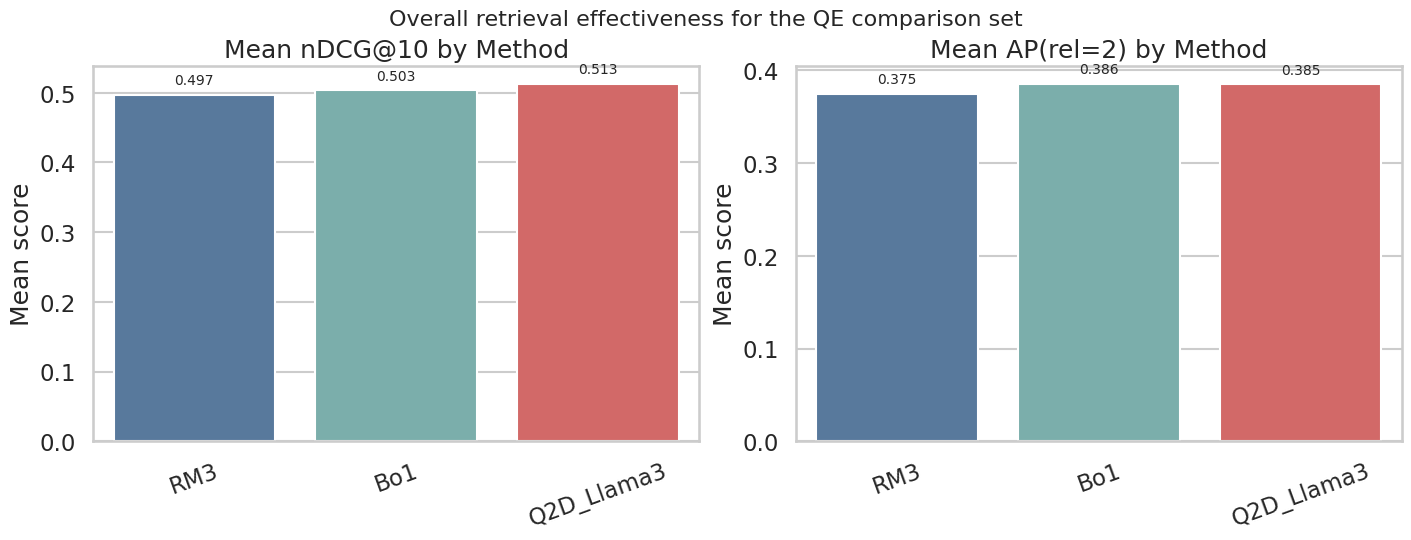

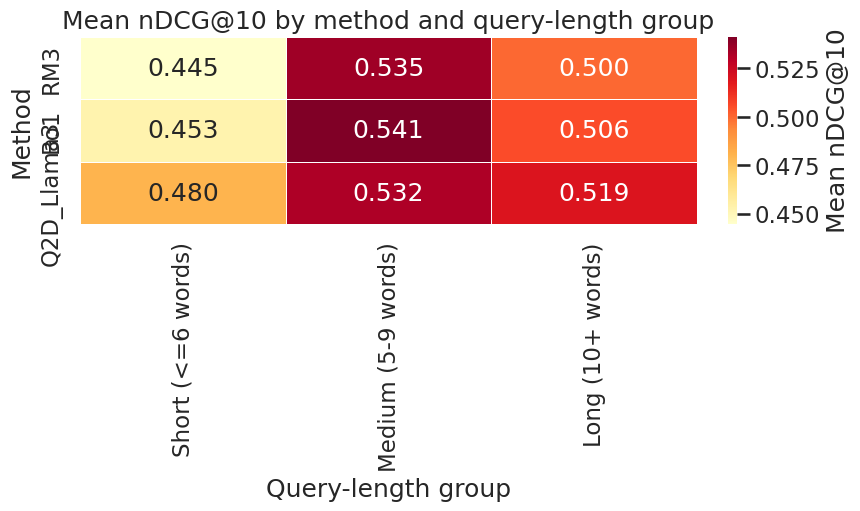

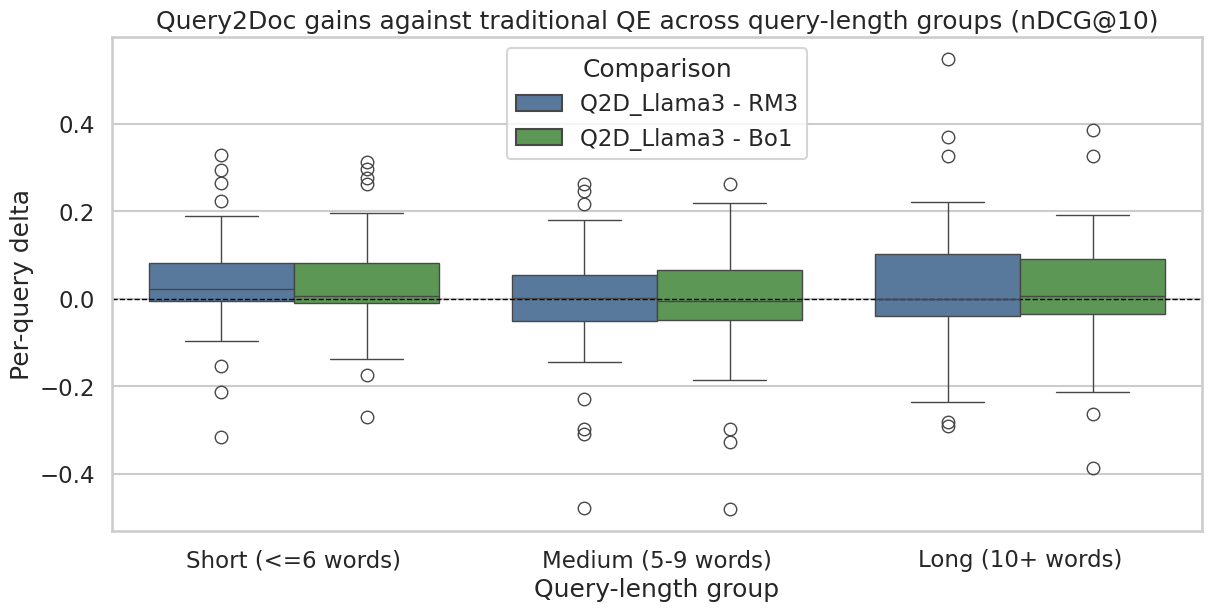

In [33]:
# Statistical test changes: create report-ready visualizations for the revised query-length analysis
# and save them under figures/statistical-tests.
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", context="talk")
stat_fig_dir = Path("figures") / "statistical-tests"
stat_fig_dir.mkdir(parents=True, exist_ok=True)

stat_method_order_full = [
    name for name in ["RM3", "Bo1", "Q2D_Llama3", "CoT"]
    if name in stat_length_results["name"].unique()
]
stat_method_palette = {
    "RM3": "#4C78A8",
    "Bo1": "#72B7B2",
    "Q2D_Llama3": "#E45756",
    "CoT": "#F2CF5B",
}
stat_comparison_palette = {
    f"{stat_target_method} - RM3": "#4C78A8",
    f"{stat_target_method} - Bo1": "#54A24B",
}


def stat_save_figure(fig, stem):
    fig.savefig(stat_fig_dir / f"{stem}.png", dpi=300, bbox_inches="tight")
    fig.savefig(stat_fig_dir / f"{stem}.pdf", bbox_inches="tight")


def stat_annotate_bars(ax, fmt="{:.3f}"):
    ymin, ymax = ax.get_ylim()
    offset = (ymax - ymin) * 0.02 if ymax > ymin else 0.02
    for patch in ax.patches:
        height = patch.get_height()
        if np.isnan(height):
            continue
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            height + offset,
            fmt.format(height),
            ha="center",
            va="bottom",
            fontsize=10,
        )


length_overall_plot = (
    stat_length_results[stat_length_results["measure"].isin(["nDCG@10", "AP(rel=2)"])]
    .groupby(["name", "measure"], as_index=False)["value"]
    .mean()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
for ax, measure, title in zip(
    axes,
    ["nDCG@10", "AP(rel=2)"],
    ["Mean nDCG@10 by Method", "Mean AP(rel=2) by Method"],
):
    plot_df = length_overall_plot[length_overall_plot["measure"] == measure].copy()
    sns.barplot(
        data=plot_df,
        x="name",
        y="value",
        order=stat_method_order_full,
        palette=[stat_method_palette[name] for name in stat_method_order_full],
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("Mean score")
    ax.tick_params(axis="x", rotation=20)
    stat_annotate_bars(ax)
fig.suptitle("Overall retrieval effectiveness for the QE comparison set", y=1.05, fontsize=16)
stat_save_figure(fig, "query_length_overall_effectiveness")
plt.show()

length_heatmap = (
    stat_length_results[stat_length_results["measure"] == "nDCG@10"]
    .groupby(["name", "query_length_group"], as_index=False)["value"]
    .mean()
    .pivot(index="name", columns="query_length_group", values="value")
    .reindex(index=stat_method_order_full, columns=stat_length_order)
)

fig, ax = plt.subplots(figsize=(8.5, 5), constrained_layout=True)
sns.heatmap(
    length_heatmap,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Mean nDCG@10"},
    ax=ax,
)
ax.set_title("Mean nDCG@10 by method and query-length group")
ax.set_xlabel("Query-length group")
ax.set_ylabel("Method")
stat_save_figure(fig, "query_length_ndcg_heatmap")
plt.show()

length_delta_plot = stat_length_delta_results[
    (stat_length_delta_results["measure"] == "nDCG@10")
    & (stat_length_delta_results["comparison"].isin(stat_comparison_order))
    & (stat_length_delta_results["query_length_group"].notna())
].copy()

fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)
sns.boxplot(
    data=length_delta_plot,
    x="query_length_group",
    y="delta",
    hue="comparison",
    order=stat_length_order,
    hue_order=stat_comparison_order,
    palette=[stat_comparison_palette[name] for name in stat_comparison_order],
    ax=ax,
)
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Query2Doc gains against traditional QE across query-length groups (nDCG@10)")
ax.set_xlabel("Query-length group")
ax.set_ylabel("Per-query delta")
ax.legend(title="Comparison", frameon=True)
stat_save_figure(fig, "query_length_q2d_gain_boxplot")
plt.show()
